In [1]:
import os
os.listdir()

['.ipynb_checkpoints',
 '.~lock.resultats.csv#',
 'crible',
 'crible.c',
 'resultats.csv',
 'test.sh',
 'Untitled.ipynb']

In [21]:
import pandas as pd
data = pd.read_csv("resultats.csv")
data

,n,temp de calcul,Temps d'execution
0,10,0.000005,0.000001
1,100,0.000006,0.000001
2,1000,0.000008,0.000003
3,10000,0.000041,0.000037
4,100000,0.000528,0.000525
5,1000000,0.005165,0.005162
6,10000000,0.166117,0.166127
7,100000000,2.079055,2.079859


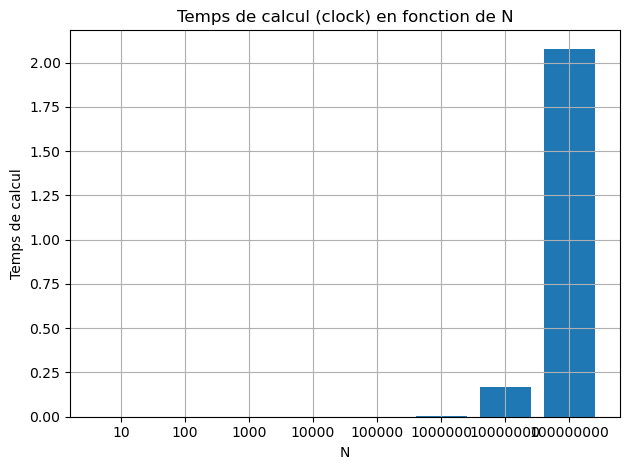

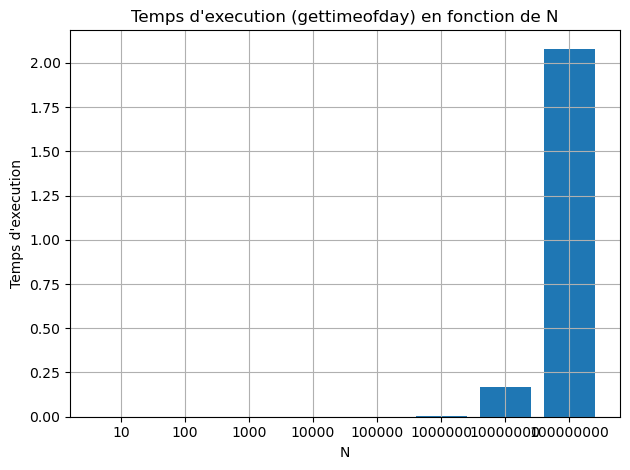

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("resultats.csv")
df.columns = [c.strip() for c in df.columns]

df = df.rename(columns={
    "n": "N",
    "temp de calcul": "CPU",
    "Temps d'execution": "EXEC"
})

df["N"] = pd.to_numeric(df["N"], errors="coerce")
df["CPU"] = pd.to_numeric(df["CPU"], errors="coerce")
df["EXEC"] = pd.to_numeric(df["EXEC"], errors="coerce")
df = df.dropna(subset=["N", "CPU", "EXEC"]).sort_values("N")

x = range(len(df))
labels = df["N"].astype(int).astype(str)

plt.figure()
plt.bar(x, df["CPU"])
plt.xticks(x, labels)
plt.xlabel("N")
plt.ylabel("Temps de calcul")
plt.title("Temps de calcul (clock) en fonction de N")
plt.grid(True)
plt.tight_layout()
plt.savefig("graph_temps_calcul.png", dpi=200)
plt.show()

plt.figure()
plt.bar(x, df["EXEC"])
plt.xticks(x, labels)
plt.xlabel("N")
plt.ylabel("Temps d'execution")
plt.title("Temps d'execution (gettimeofday) en fonction de N")
plt.grid(True)
plt.tight_layout()
plt.savefig("graph_temps_execution.png", dpi=200)
plt.show()
